# 🎯 Pipeline FPD — Hackathon TMB × PIT

## Melhorias aplicadas em relação ao pipeline original

| # | Melhoria | Justificativa |
|---|----------|---------------|
| 1 | **Remoção rigorosa de leakage** | Regra inegociável: não usar colunas pós-evento (status_cobranca, dias_em_atraso, recebido, etc.). |
| 2 | **Split TEMPORAL (não random)** | PDF lista "random split" como erro que elimina soluções. Treinar no passado, avaliar no futuro. |
| 3 | **Frequency encoding** em produtor/lançamento | Alta cardinalidade — one-hot explodiria a dimensionalidade. |
| 4 | **6 estratégias de balanceamento** | baseline, class_weight, SMOTE, ADASYN, RandomUnderSampler, SMOTEENN |
| 5 | **5 modelos comparados** | LogReg, RandomForest, ExtraTrees, XGBoost, LightGBM |
| 6 | **Métricas profissionais** | ROC-AUC, PR-AUC, **KS** (clássica de crédito), F1, **Recall top-10%/20%** |
| 7 | **Otimização com Optuna** | Tuning bayesiano (TPE) nos top-3 — mais eficiente que GridSearch |
| 8 | **Validação cruzada** durante tuning | StratifiedKFold para estimativas robustas |
| 9 | **Tabela de decis + lift** | Resposta à pergunta da banca: "quanto FPD nos top X%?" |
| 10 | **Submissão no formato oficial** | `pedido_id, prob_fpd, faixa_risco` |

---


## 1️⃣ Imports e configuração

In [1]:
# Instale o que faltar com:
#   pip install pandas numpy scikit-learn xgboost lightgbm imbalanced-learn optuna matplotlib seaborn scipy openpyxl

import pandas as pd
import numpy as np
import re
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, precision_score, recall_score,
                              confusion_matrix, roc_curve, precision_recall_curve)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from scipy.stats import ks_2samp

SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', None)
print('✅ Bibliotecas carregadas')

✅ Bibliotecas carregadas


## 2️⃣ Carregamento dos dados

In [2]:
ARQUIVO = 'basetreinamento.xlsx'
df = pd.read_excel(ARQUIVO, nrows=5000)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (5000, 56)


,pedido_id,CPF,SCORE_HCP4,SCORE_HCP5,SCORE_HEST,SCORE_HFI4,SCORE_HFI5,HI01_PROB,HI01_CONCEITO,SCORE_HIPA,SCORE_HIPN,HPG5,HCR5,H5OR,SCORE_HRM5,SCORE_HSV4,SCORE_HSV5,SCORE_HVA4,SCORE_HVA5,MENSAGEM_TIPO_REGISTRO,FPD,produtor,lancamento,segmento,status_cobranca,status_financeiro,status_pedido,nome,email,score,categoria_risco_score,documento,endereco_cep,endereco_estado,endereco_cidade,nascimento,idade,telefone_ativo,modalidade,total_financiado,quantidade_parcelas,saldo_vencido,quantidade_parcelas_vencidas,recebido,primeiro_vencimento_em_atraso,dias_em_atraso,pdd,saldo_vencido_com_juros,total_pago_com_juros,aguardando_pagamento_sem_juros,vencidos_sem_juros_tmb,recebido_sem_juros_tmb,data_efetivacao,data_quitacao,order_bump,pedido_pai_ob
0,26414,D6CEA19DCA,567,567,1,558,570,NaN,NaN,99,100,NaN,NaN,NaN,NaN,500,538,458,494,APTOS,NÃ£o,Produtor_1583,Lancamento_2563,Autoconhecimento,CobranÃ§a Interna,Inadimplente,Efetivado,Cliente_25AAFE70,user_6DDD6F8B@anon.local,130,Alto,D6CEA19DCA,88220000,Santa Catarina,Cidade_1893,1978-12-12 00:00:00,47,BDECE65488,Compartilhado,1944.22,13.0,743.7,5.0,1200.52,2024-11-20 00:00:00,434,False,743.7,1244.15,NaN,533.25,932.35,2024-08-21 16:48:00,NaT,NaT,NaN
1,60182,BC8B4630C6,580,567,6,679,621,0.099992,0.0,99,94,191.0,88.0,50698.0,1599.0,575,623,673,598,APTOS,NÃ£o,Produtor_0238,Lancamento_2456,Empreendedor,NaN,Adimplente,Cancelamento Solicitado,Cliente_45B91102,user_9612B4E0@anon.local,196,Alto,BC8B4630C6,39540000,MG,Cidade_3985,1981-09-14 00:00:00,44,6F2C9BC475,Compartilhado,129.7,1.0,NaN,0.0,129.70,NaN,NaN,False,NaN,129.70,NaN,NaN,97.28,2024-06-07 00:12:00,NaT,NaT,NaN
2,938745,BC8B4630C6,580,567,6,679,621,0.099992,0.0,99,94,191.0,88.0,50698.0,1599.0,575,623,673,598,APTOS,NÃ£o,Produtor_0181,Lancamento_2660,Empreendedor,NaN,Quitado,Efetivado,Cliente_CF1B01F0,user_9612B4E0@anon.local,710,Baixo,BC8B4630C6,39540-000,MG,Cidade_3985,1981-09-14 00:00:00,44,56C8E4B75C,Antecipado,1796.04,12.0,NaN,0.0,1796.04,NaN,NaN,False,NaN,1820.73,NaN,NaN,1497.00,2024-06-07 21:59:00,2025-07-17 00:15:00,NaT,NaN


## 3️⃣ Limpeza: remoção de leakage

> Regra inegociável do desafio: o modelo deve usar apenas informações disponíveis no momento do checkout.


In [3]:
# 1) Colunas pós-evento — LEAKAGE
LEAKAGE_COLS = [
    'status_cobranca', 'status_financeiro', 'status_pedido',
    'saldo_vencido', 'quantidade_parcelas_vencidas', 'recebido',
    'primeiro_vencimento_em_atraso', 'dias_em_atraso', 'pdd',
    'saldo_vencido_com_juros', 'total_pago_com_juros',
    'aguardando_pagamento_sem_juros', 'vencidos_sem_juros_tmb',
    'recebido_sem_juros_tmb', 'data_quitacao',
]

# 2) Identificadores / PII
ID_COLS = [
    'pedido_id', 'CPF', 'documento', 'documento2', 'nome', 'email',
    'telefone_ativo', 'endereco_cep', 'endereco_cidade', 'pedido_pai_ob',
]

cols_to_drop = [c for c in (LEAKAGE_COLS + ID_COLS) if c in df.columns]
df_clean = df.drop(columns=cols_to_drop).copy()

print(f'🗑️  Removidas {len(cols_to_drop)} colunas: {cols_to_drop}')
print(f'📉 Shape após limpeza: {df_clean.shape}')

🗑️  Removidas 24 colunas: ['status_cobranca', 'status_financeiro', 'status_pedido', 'saldo_vencido', 'quantidade_parcelas_vencidas', 'recebido', 'primeiro_vencimento_em_atraso', 'dias_em_atraso', 'pdd', 'saldo_vencido_com_juros', 'total_pago_com_juros', 'aguardando_pagamento_sem_juros', 'vencidos_sem_juros_tmb', 'recebido_sem_juros_tmb', 'data_quitacao', 'pedido_id', 'CPF', 'documento', 'nome', 'email', 'telefone_ativo', 'endereco_cep', 'endereco_cidade', 'pedido_pai_ob']
📉 Shape após limpeza: (5000, 32)


## 4️⃣ Target FPD

In [4]:
def map_fpd(v):
    s = str(v).strip().lower()
    if 'sim' in s or s == 's' or s == '1':
        return 1
    return 0

df_clean['FPD'] = df['FPD'].apply(map_fpd).astype(int)
print(df_clean['FPD'].value_counts())
print(f'Taxa positiva: {df_clean["FPD"].mean():.2%}')

FPD
0    4203
1     797
Name: count, dtype: int64
Taxa positiva: 15.94%


## 5️⃣ Feature engineering

In [ ]:
hoje = datetime.today()

def fix_idade(v):
    if pd.isna(v): return np.nan
    if isinstance(v, (int, float)): return float(v)
    if isinstance(v, (datetime, pd.Timestamp)):
        return (hoje - v).days // 365
    return np.nan

df_clean['idade'] = df_clean['idade'].apply(fix_idade)
df_clean['idade'] = pd.to_numeric(df_clean['idade'], errors='coerce') 

if 'nascimento' in df_clean.columns:
    nasc = pd.to_datetime(df_clean['nascimento'], errors='coerce')
    df_clean['idade'] = df_clean['idade'].fillna((hoje - nasc).dt.days // 365)
    df_clean = df_clean.drop(columns=['nascimento'])

df_clean['idade'] = pd.to_numeric(df_clean['idade'], errors='coerce')  

df_clean['data_efetivacao'] = pd.to_datetime(df_clean['data_efetivacao'], errors='coerce')
df_clean['hora_compra'] = df_clean['data_efetivacao'].dt.hour

def periodo_do_dia(h):
    if pd.isna(h): return 'desconhecido'
    if 0 <= h < 6:   return 'madrugada'
    if 6 <= h < 12:  return 'manha'
    if 12 <= h < 18: return 'tarde'
    return 'noite'

df_clean['periodo_compra'] = df_clean['hora_compra'].apply(periodo_do_dia)
df_clean['compra_noturna'] = ((df_clean['hora_compra'] >= 22) |
                               (df_clean['hora_compra'] < 6)).astype(int)
df_clean['data_efetivacao'] = df_clean['data_efetivacao'].dt.normalize()

for c in ['total_financiado', 'quantidade_parcelas', 'score']:
    if c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')

if 'categoria_risco_score' in df_clean.columns:
    df_clean = df_clean.drop(columns=['categoria_risco_score'])

if 'endereco_estado' in df_clean.columns:
    df_clean['endereco_estado'] = (df_clean['endereco_estado']
        .astype(str).str.strip().str.upper().str[:2])

for col in ['produtor', 'lancamento']:
    if col in df_clean.columns:
        freq = df_clean[col].value_counts(normalize=True)
        df_clean[col + '_freq'] = df_clean[col].map(freq)
        df_clean = df_clean.drop(columns=[col])

cat_cols = [c for c in ['segmento', 'modalidade', 'MENSAGEM_TIPO_REGISTRO',
                          'endereco_estado', 'order_bump', 'periodo_compra']
            if c in df_clean.columns]
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True, dummy_na=True)
df_clean.columns = [re.sub(r'[^\w]', '_', c) for c in df_clean.columns]

obj_cols = df_clean.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print(f'⚠️  Removendo objects não tratados: {obj_cols}')
    df_clean = df_clean.drop(columns=obj_cols)

print(f'✅ Shape final: {df_clean.shape}')
print(f'NaT em data_efetivacao: {df_clean["data_efetivacao"].isna().sum()}')

✅ Shape final: (5000, 80)
NaT em data_efetivacao: 0


## 6️⃣ Split TEMPORAL 


- **80% mais antigos** → treino
- **20% mais recentes** → teste 


In [6]:
df_clean = df_clean.dropna(subset=['data_efetivacao']).reset_index(drop=True)  
df_clean = df_clean.sort_values('data_efetivacao').reset_index(drop=True)
corte = int(len(df_clean) * 0.8)

print(f'📅 Treino: {df_clean["data_efetivacao"].iloc[:corte].min()} → {df_clean["data_efetivacao"].iloc[:corte].max()}')
print(f'📅 Teste:  {df_clean["data_efetivacao"].iloc[corte:].min()} → {df_clean["data_efetivacao"].iloc[corte:].max()}')

train_df = df_clean.iloc[:corte].drop(columns=['data_efetivacao'])
test_df  = df_clean.iloc[corte:].drop(columns=['data_efetivacao'])

y_train = train_df['FPD'].astype(int); X_train = train_df.drop(columns=['FPD'])
y_test  = test_df['FPD'].astype(int);  X_test  = test_df.drop(columns=['FPD'])

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),  columns=X_test.columns)

print(f'\nX_train: {X_train.shape}, taxa FPD: {y_train.mean():.2%}')
print(f'X_test:  {X_test.shape}, taxa FPD: {y_test.mean():.2%}')

📅 Treino: 1970-01-01 00:00:00 → 2024-03-21 00:00:00
📅 Teste:  2024-03-22 00:00:00 → 2025-07-31 00:00:00

X_train: (4000, 78), taxa FPD: 17.20%
X_test:  (1000, 78), taxa FPD: 10.90%


## 7️⃣ Funções de avaliação



In [7]:
def ks_statistic(y_true, y_proba):
    return ks_2samp(y_proba[y_true == 1], y_proba[y_true == 0]).statistic

def top_q_recall(y_true, y_proba, q=0.10):
    n_top = max(int(len(y_proba) * q), 1)
    idx_top = np.argsort(-y_proba)[:n_top]
    return y_true.iloc[idx_top].sum() / max(y_true.sum(), 1)

def evaluate_model(model, X_te, y_te, threshold=0.5):
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        'ROC_AUC': roc_auc_score(y_te, proba),
        'PR_AUC':  average_precision_score(y_te, proba),
        'KS':      ks_statistic(y_te.values, proba),
        'F1':      f1_score(y_te, pred),
        'Precision': precision_score(y_te, pred, zero_division=0),
        'Recall':  recall_score(y_te, pred),
        'Top10%':  top_q_recall(y_te, proba, 0.10),
        'Top20%':  top_q_recall(y_te, proba, 0.20),
    }

## 8️⃣ Estratégias de balanceamento



In [8]:
def get_resampled(strategy, X, y, seed=SEED):
    if strategy in ('baseline', 'class_weight'):
        return X, y
    if strategy == 'SMOTE':
        return SMOTE(random_state=seed, k_neighbors=5).fit_resample(X, y)
    if strategy == 'ADASYN':
        return ADASYN(random_state=seed, n_neighbors=5).fit_resample(X, y)
    if strategy == 'UnderSample':
        return RandomUnderSampler(random_state=seed).fit_resample(X, y)
    if strategy == 'SMOTEENN':
        return SMOTEENN(random_state=seed).fit_resample(X, y)
    raise ValueError(strategy)

STRATEGIES = ['baseline', 'class_weight', 'SMOTE', 'ADASYN', 'UnderSample', 'SMOTEENN']
print('Estratégias:', STRATEGIES)

Estratégias: ['baseline', 'class_weight', 'SMOTE', 'ADASYN', 'UnderSample', 'SMOTEENN']


## 9️⃣ Configuração dos modelos

In [9]:
def build_models(use_class_weight=False):
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    return {
        'LogReg':       LogisticRegression(max_iter=2000, random_state=SEED, n_jobs=-1,
                                          class_weight='balanced' if use_class_weight else None),
        'RandomForest': RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                                              class_weight='balanced' if use_class_weight else None),
        'ExtraTrees':   ExtraTreesClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                                            class_weight='balanced' if use_class_weight else None),
        'XGBoost':      XGBClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                                      use_label_encoder=False, eval_metric='auc',
                                      scale_pos_weight=scale_pos_weight if use_class_weight else 1),
        'LightGBM':     LGBMClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, verbose=-1,
                                       class_weight='balanced' if use_class_weight else None),
    }

print('Modelos:', list(build_models().keys()))

Modelos: ['LogReg', 'RandomForest', 'ExtraTrees', 'XGBoost', 'LightGBM']


## 🔟 Grid de experimentos: 



In [10]:
scaler_global = StandardScaler()
X_train_sc = pd.DataFrame(scaler_global.fit_transform(X_train), columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler_global.transform(X_test),  columns=X_test.columns)

results = []

for strat in STRATEGIES:
    use_cw = (strat == 'class_weight')
    X_tr_r, y_tr_r = get_resampled(strat, X_train, y_train)
    
    print(f'\n--- {strat} | n={len(X_tr_r)} | pos={int((y_tr_r==1).sum())} ---')
    
    for mname, model in build_models(use_class_weight=use_cw).items():
        try:
            if mname == 'LogReg':
                if strat in ('baseline', 'class_weight'):
                    X_tr_use, X_te_use = X_train_sc, X_test_sc
                    y_tr_use = y_train
                else:
                    sc = StandardScaler()
                    X_tr_use = pd.DataFrame(sc.fit_transform(X_tr_r), columns=X_tr_r.columns)
                    X_te_use = pd.DataFrame(sc.transform(X_test), columns=X_test.columns)
                    y_tr_use = y_tr_r
                model.fit(X_tr_use, y_tr_use)
                metrics = evaluate_model(model, X_te_use, y_test)
            else:
                model.fit(X_tr_r, y_tr_r)
                metrics = evaluate_model(model, X_test, y_test)
            
            results.append({'modelo': mname, 'balanceamento': strat, **metrics})
            print(f'  {mname:14s} ROC={metrics["ROC_AUC"]:.3f}  KS={metrics["KS"]:.3f}  F1={metrics["F1"]:.3f}  Top10%={metrics["Top10%"]:.3f}')
        except Exception as e:
            print(f'  {mname:14s} FALHOU: {e}')

df_results = pd.DataFrame(results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
df_results.round(4)


--- baseline | n=4000 | pos=688 ---
  LogReg         ROC=0.738  KS=0.401  F1=0.065  Top10%=0.239
  RandomForest   ROC=0.774  KS=0.437  F1=0.068  Top10%=0.321
  ExtraTrees     ROC=0.761  KS=0.429  F1=0.051  Top10%=0.257
  XGBoost        ROC=0.764  KS=0.416  F1=0.245  Top10%=0.284
  LightGBM       ROC=0.768  KS=0.415  F1=0.187  Top10%=0.284

--- class_weight | n=4000 | pos=688 ---
  LogReg         ROC=0.739  KS=0.402  F1=0.324  Top10%=0.239
  RandomForest   ROC=0.794  KS=0.435  F1=0.100  Top10%=0.367
  ExtraTrees     ROC=0.764  KS=0.407  F1=0.052  Top10%=0.229
  XGBoost        ROC=0.766  KS=0.425  F1=0.300  Top10%=0.303
  LightGBM       ROC=0.754  KS=0.412  F1=0.246  Top10%=0.275

--- SMOTE | n=6624 | pos=3312 ---
  LogReg         ROC=0.745  KS=0.401  F1=0.329  Top10%=0.248
  RandomForest   ROC=0.797  KS=0.490  F1=0.121  Top10%=0.266
  ExtraTrees     ROC=0.764  KS=0.431  F1=0.129  Top10%=0.239
  XGBoost        ROC=0.754  KS=0.402  F1=0.218  Top10%=0.303
  LightGBM       ROC=0.755  KS=0.

,modelo,balanceamento,ROC_AUC,PR_AUC,KS,F1,Precision,Recall,Top10%,Top20%
0,RandomForest,SMOTEENN,0.8121,0.3244,0.5305,0.3988,0.2931,0.6239,0.3028,0.5596
1,RandomForest,UnderSample,0.8004,0.3035,0.4997,0.3730,0.2500,0.7339,0.2752,0.5596
2,RandomForest,SMOTE,0.7967,0.2869,0.4901,0.1212,0.3478,0.0734,0.2661,0.5229
3,LightGBM,SMOTEENN,0.7961,0.2998,0.4976,0.3729,0.2957,0.5046,0.2752,0.5229
4,RandomForest,class_weight,0.7944,0.3403,0.4354,0.1000,0.5455,0.0550,0.3670,0.5413
5,ExtraTrees,SMOTEENN,0.7930,0.2868,0.4906,0.3670,0.2752,0.5505,0.2661,0.5138
6,XGBoost,SMOTEENN,0.7923,0.3008,0.5139,0.3510,0.2746,0.4862,0.3028,0.4954
7,RandomForest,ADASYN,0.7867,0.2891,0.4605,0.1077,0.3333,0.0642,0.2936,0.5413
8,RandomForest,baseline,0.7741,0.3144,0.4369,0.0684,0.5000,0.0367,0.3211,0.4862
9,LogReg,SMOTEENN,0.7706,0.2733,0.4532,0.3321,0.2067,0.8440,0.2752,0.4862


## 1️⃣1️⃣ Visualização comparativa

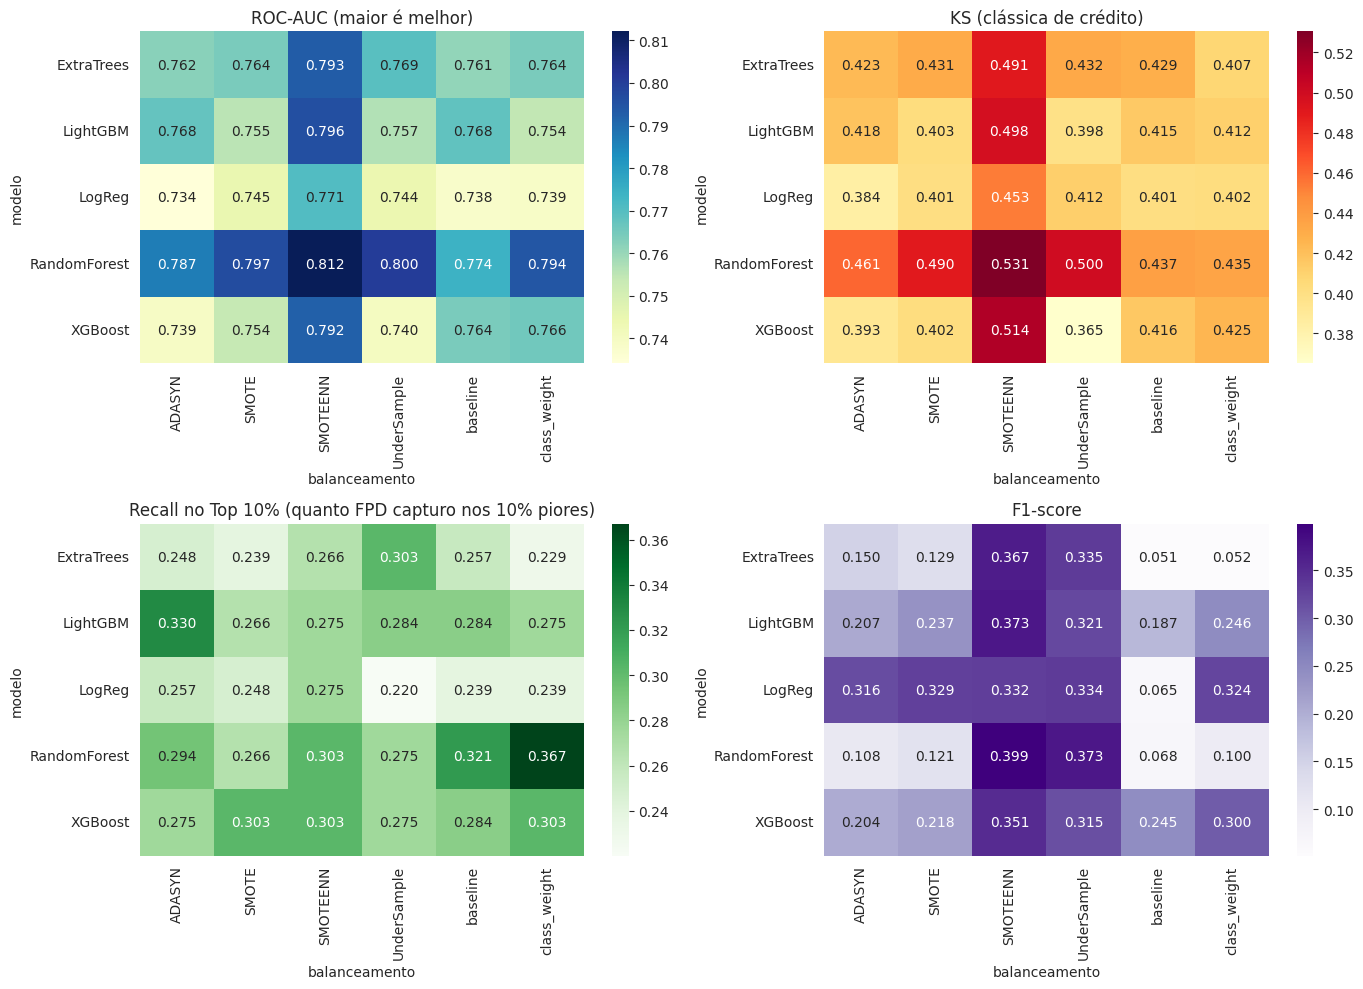

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pivot_roc = df_results.pivot(index='modelo', columns='balanceamento', values='ROC_AUC')
sns.heatmap(pivot_roc, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0,0])
axes[0,0].set_title('ROC-AUC (maior é melhor)')

pivot_ks = df_results.pivot(index='modelo', columns='balanceamento', values='KS')
sns.heatmap(pivot_ks, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0,1])
axes[0,1].set_title('KS (clássica de crédito)')

pivot_top = df_results.pivot(index='modelo', columns='balanceamento', values='Top10%')
sns.heatmap(pivot_top, annot=True, fmt='.3f', cmap='Greens', ax=axes[1,0])
axes[1,0].set_title('Recall no Top 10% (quanto FPD capturo nos 10% piores)')

pivot_f1 = df_results.pivot(index='modelo', columns='balanceamento', values='F1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Purples', ax=axes[1,1])
axes[1,1].set_title('F1-score')

plt.tight_layout()
plt.show()

## 1️⃣2️⃣ Top-3 combinações para tuning

In [12]:
top3 = df_results.head(3).reset_index(drop=True)
print('🏆 TOP 3 combinações que irão para tuning:')
top3[['modelo','balanceamento','ROC_AUC','PR_AUC','KS','F1','Top10%']]

🏆 TOP 3 combinações que irão para tuning:


,modelo,balanceamento,ROC_AUC,PR_AUC,KS,F1,Top10%
0,RandomForest,SMOTEENN,0.812148,0.324402,0.530514,0.398827,0.302752
1,RandomForest,UnderSample,0.800415,0.303520,0.499727,0.372960,0.275229
2,RandomForest,SMOTE,0.796657,0.286909,0.490059,0.121212,0.266055


## 1️⃣3️⃣ Otimização de hiperparâmetros com Optuna



In [13]:
def cv_score(params, model_name, strat, X, y, n_splits=3):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    scores = []
    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        X_tr_r, y_tr_r = get_resampled(strat, X_tr, y_tr)
        use_cw = (strat == 'class_weight')
        
        if model_name == 'XGBoost':
            spw = (y_tr==0).sum() / max((y_tr==1).sum(), 1)
            m = XGBClassifier(**params, random_state=SEED, n_jobs=-1,
                              use_label_encoder=False, eval_metric='auc',
                              scale_pos_weight=spw if use_cw else 1)
        elif model_name == 'LightGBM':
            m = LGBMClassifier(**params, random_state=SEED, n_jobs=-1, verbose=-1,
                               class_weight='balanced' if use_cw else None)
        elif model_name == 'RandomForest':
            m = RandomForestClassifier(**params, random_state=SEED, n_jobs=-1,
                                       class_weight='balanced' if use_cw else None)
        elif model_name == 'ExtraTrees':
            m = ExtraTreesClassifier(**params, random_state=SEED, n_jobs=-1,
                                     class_weight='balanced' if use_cw else None)
        elif model_name == 'LogReg':
            sc = StandardScaler()
            X_tr_r = pd.DataFrame(sc.fit_transform(X_tr_r), columns=X_tr_r.columns)
            X_va = pd.DataFrame(sc.transform(X_va), columns=X_va.columns)
            m = LogisticRegression(**params, max_iter=3000, random_state=SEED, n_jobs=-1,
                                   class_weight='balanced' if use_cw else None)
        
        m.fit(X_tr_r, y_tr_r)
        scores.append(roc_auc_score(y_va, m.predict_proba(X_va)[:, 1]))
    return np.mean(scores)

def make_objective(model_name, strat, X, y):
    def objective(trial):
        if model_name == 'XGBoost':
            params = dict(
                n_estimators=trial.suggest_int('n_estimators', 100, 600),
                max_depth=trial.suggest_int('max_depth', 3, 10),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
                reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
                reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
                min_child_weight=trial.suggest_int('min_child_weight', 1, 20),
            )
        elif model_name == 'LightGBM':
            params = dict(
                n_estimators=trial.suggest_int('n_estimators', 100, 600),
                num_leaves=trial.suggest_int('num_leaves', 15, 200),
                max_depth=trial.suggest_int('max_depth', 3, 12),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
                reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
                reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
                min_child_samples=trial.suggest_int('min_child_samples', 5, 100),
            )
        elif model_name in ('RandomForest', 'ExtraTrees'):
            params = dict(
                n_estimators=trial.suggest_int('n_estimators', 100, 600),
                max_depth=trial.suggest_int('max_depth', 4, 25),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 20),
                max_features=trial.suggest_categorical('max_features', ['sqrt','log2', 0.5]),
            )
        elif model_name == 'LogReg':
            params = dict(
                C=trial.suggest_float('C', 1e-3, 100, log=True),
                penalty=trial.suggest_categorical('penalty', ['l1','l2']),
                solver='liblinear',
            )
        return cv_score(params, model_name, strat, X, y)
    return objective

tuning_results = []
best_models = {}
N_TRIALS = 30

for i, row in top3.iterrows():
    mname, strat = row['modelo'], row['balanceamento']
    print(f'\n=== TUNING {i+1}/3: {mname} + {strat} ===')
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(make_objective(mname, strat, X_train, y_train),
                   n_trials=N_TRIALS, show_progress_bar=False)
    
    best_params = study.best_params
    print(f'  CV ROC-AUC: {study.best_value:.4f}')
    print(f'  params: {best_params}')
    
    X_tr_r, y_tr_r = get_resampled(strat, X_train, y_train)
    use_cw = (strat == 'class_weight')
    
    if mname == 'XGBoost':
        spw = (y_train==0).sum() / max((y_train==1).sum(), 1)
        final = XGBClassifier(**best_params, random_state=SEED, n_jobs=-1,
                              use_label_encoder=False, eval_metric='auc',
                              scale_pos_weight=spw if use_cw else 1)
    elif mname == 'LightGBM':
        final = LGBMClassifier(**best_params, random_state=SEED, n_jobs=-1, verbose=-1,
                               class_weight='balanced' if use_cw else None)
    elif mname == 'RandomForest':
        final = RandomForestClassifier(**best_params, random_state=SEED, n_jobs=-1,
                                       class_weight='balanced' if use_cw else None)
    elif mname == 'ExtraTrees':
        final = ExtraTreesClassifier(**best_params, random_state=SEED, n_jobs=-1,
                                     class_weight='balanced' if use_cw else None)
    elif mname == 'LogReg':
        sc_final = StandardScaler()
        X_tr_r = pd.DataFrame(sc_final.fit_transform(X_tr_r), columns=X_tr_r.columns)
        X_te_use = pd.DataFrame(sc_final.transform(X_test), columns=X_test.columns)
        final = LogisticRegression(**best_params, max_iter=3000, random_state=SEED, n_jobs=-1,
                                   class_weight='balanced' if use_cw else None)
    
    if mname == 'LogReg':
        final.fit(X_tr_r, y_tr_r)
        metrics_final = evaluate_model(final, X_te_use, y_test)
    else:
        final.fit(X_tr_r, y_tr_r)
        metrics_final = evaluate_model(final, X_test, y_test)
    
    tuning_results.append({
        'modelo': mname, 'balanceamento': strat,
        'cv_best_auc': study.best_value,
        **metrics_final,
        'best_params': best_params
    })
    best_models[f'{mname}_{strat}'] = final

df_tuned = pd.DataFrame(tuning_results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
print('\n🏆 RESULTADO PÓS-TUNING:')
df_tuned[['modelo','balanceamento','cv_best_auc','ROC_AUC','PR_AUC','KS','F1','Top10%']]


=== TUNING 1/3: RandomForest + SMOTEENN ===
  CV ROC-AUC: 0.7355
  params: {'n_estimators': 356, 'max_depth': 16, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2'}

=== TUNING 2/3: RandomForest + UnderSample ===
  CV ROC-AUC: 0.7424
  params: {'n_estimators': 431, 'max_depth': 19, 'min_samples_split': 17, 'min_samples_leaf': 2, 'max_features': 'log2'}

=== TUNING 3/3: RandomForest + SMOTE ===
  CV ROC-AUC: 0.7306
  params: {'n_estimators': 537, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2'}

🏆 RESULTADO PÓS-TUNING:


,modelo,balanceamento,cv_best_auc,ROC_AUC,PR_AUC,KS,F1,Top10%
0,RandomForest,SMOTEENN,0.735542,0.818038,0.335476,0.525531,0.399002,0.321101
1,RandomForest,UnderSample,0.742393,0.803283,0.296085,0.481574,0.354212,0.311927
2,RandomForest,SMOTE,0.730626,0.803138,0.286957,0.507676,0.264550,0.293578


## 1️⃣4️⃣ Antes vs depois do tuning

In [14]:
comp = top3[['modelo','balanceamento','ROC_AUC','KS','F1']].rename(
    columns={'ROC_AUC':'ROC_antes', 'KS':'KS_antes', 'F1':'F1_antes'}
).merge(
    df_tuned[['modelo','balanceamento','ROC_AUC','KS','F1']].rename(
        columns={'ROC_AUC':'ROC_depois', 'KS':'KS_depois', 'F1':'F1_depois'}
    ),
    on=['modelo','balanceamento']
)
comp['ΔROC'] = (comp['ROC_depois'] - comp['ROC_antes']).round(4)
comp['ΔKS']  = (comp['KS_depois'] - comp['KS_antes']).round(4)
comp

,modelo,balanceamento,ROC_antes,KS_antes,F1_antes,ROC_depois,KS_depois,F1_depois,ΔROC,ΔKS
0,RandomForest,SMOTEENN,0.812148,0.530514,0.398827,0.818038,0.525531,0.399002,0.0059,-0.0050
1,RandomForest,UnderSample,0.800415,0.499727,0.372960,0.803283,0.481574,0.354212,0.0029,-0.0182
2,RandomForest,SMOTE,0.796657,0.490059,0.121212,0.803138,0.507676,0.264550,0.0065,0.0176


## 1️⃣5️⃣ Modelo campeão: análise detalhada

🏆 Campeão: RandomForest_SMOTEENN
   ROC-AUC: 0.8180
   KS:      0.5255
   Top 10%: 32.11%


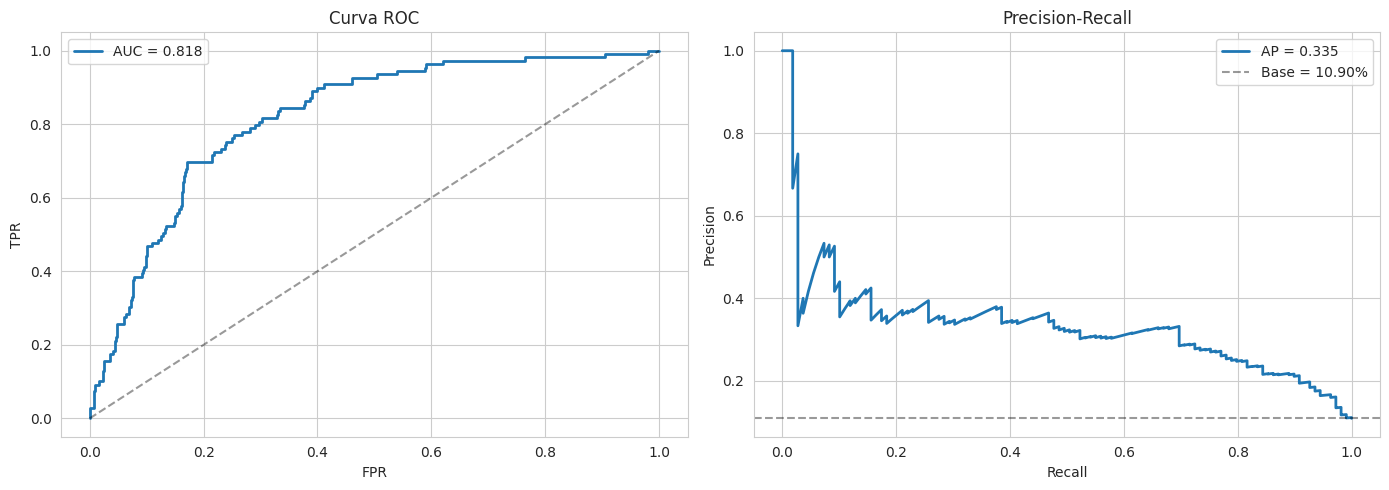

In [15]:
champ_row = df_tuned.iloc[0]
champ_name = f'{champ_row["modelo"]}_{champ_row["balanceamento"]}'
champion = best_models[champ_name]
print(f'🏆 Campeão: {champ_name}')
print(f'   ROC-AUC: {champ_row["ROC_AUC"]:.4f}')
print(f'   KS:      {champ_row["KS"]:.4f}')
print(f'   Top 10%: {champ_row["Top10%"]:.2%}')

if champ_row['modelo'] == 'LogReg':
    sc = StandardScaler()
    X_tr_r, y_tr_r = get_resampled(champ_row['balanceamento'], X_train, y_train)
    sc.fit(X_tr_r)
    proba_test = champion.predict_proba(
        pd.DataFrame(sc.transform(X_test), columns=X_test.columns))[:, 1]
else:
    proba_test = champion.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {champ_row["ROC_AUC"]:.3f}')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[0].set(xlabel='FPR', ylabel='TPR', title='Curva ROC')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, proba_test)
axes[1].plot(rec, prec, lw=2, label=f'AP = {champ_row["PR_AUC"]:.3f}')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4,
                label=f'Base = {y_test.mean():.2%}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall')
axes[1].legend()
plt.tight_layout()
plt.show()

In [16]:
# Tabela de decis (decil 1 = piores 10%)
df_decis = pd.DataFrame({'y': y_test.values, 'proba': proba_test})
df_decis['decil'] = pd.qcut(df_decis['proba'], 10, labels=False, duplicates='drop') + 1
df_decis['decil'] = 11 - df_decis['decil']

tab = df_decis.groupby('decil').agg(
    qtd=('y','size'), fpd=('y','sum'), taxa_fpd=('y','mean'),
    score_min=('proba','min'), score_max=('proba','max')
).round(4)
tab['pct_fpd_acumulado'] = (tab['fpd'].cumsum() / tab['fpd'].sum()).round(4)
tab['lift'] = (tab['taxa_fpd'] / y_test.mean()).round(2)
print('📊 Tabela de decis (decil 1 = 10% piores scores):')
tab

📊 Tabela de decis (decil 1 = 10% piores scores):


,qtd,fpd,taxa_fpd,score_min,score_max,pct_fpd_acumulado,lift
decil,,,,,,,
1,100,35,0.35,0.7138,0.9204,0.3211,3.21
2,100,26,0.26,0.5929,0.7125,0.5596,2.39
3,100,21,0.21,0.4938,0.5928,0.7523,1.93
4,100,10,0.10,0.3903,0.4936,0.8440,0.92
5,100,7,0.07,0.2867,0.3900,0.9083,0.64
6,100,4,0.04,0.2013,0.2865,0.9450,0.37
7,100,3,0.03,0.1181,0.2012,0.9725,0.28
8,100,1,0.01,0.0682,0.1173,0.9817,0.09
9,100,0,0.00,0.0314,0.0678,0.9817,0.00


## 1️⃣6️⃣ Faixas de risco para a política de cobrança

In [22]:
def classificar_faixa(p):
    if p < 0.25:  return 'Baixo'
    if p < 0.50:  return 'Medio'
    if p < 0.75:  return 'Alto'
    return 'Critico'

df_decis['faixa'] = df_decis['proba'].apply(classificar_faixa)
faixa_tab = df_decis.groupby('faixa').agg(
    qtd=('y','size'), fpd=('y','sum'), taxa_fpd=('y','mean')
).reindex(['Baixo','Medio','Alto','Critico']).round(4)
faixa_tab['lift'] = (faixa_tab['taxa_fpd'] / y_test.mean()).round(2)
print('Distribuição de faixas (base de teste):')
faixa_tab

Distribuição de faixas (base de teste):


,qtd,fpd,taxa_fpd,lift
faixa,,,,
Baixo,457,8,0.0175,0.16
Medio,251,21,0.0837,0.77
Alto,222,53,0.2387,2.19
Critico,70,27,0.3857,3.54


## 1️⃣7️⃣ Geração da submissão final

In [ ]:
df_sub = pd.read_excel('submissao.xlsx')
print(f'Submissão shape: {df_sub.shape}')

sub_pedido_id = df_sub['pedido_id'].copy()

cols_drop_sub = [c for c in (LEAKAGE_COLS + ID_COLS) if c in df_sub.columns]
df_sub_clean = df_sub.drop(columns=cols_drop_sub)

df_sub_clean['idade'] = df_sub_clean['idade'].apply(fix_idade)
if 'nascimento' in df_sub_clean.columns:
    nasc = pd.to_datetime(df_sub_clean['nascimento'], errors='coerce')
    df_sub_clean['idade'] = df_sub_clean['idade'].fillna((hoje - nasc).dt.days // 365)
    df_sub_clean = df_sub_clean.drop(columns=['nascimento'])
    
df_sub_clean['data_efetivacao'] = pd.to_datetime(df_sub_clean['data_efetivacao'], errors='coerce')
df_sub_clean['hora_compra'] = df_sub_clean['data_efetivacao'].dt.hour
df_sub_clean['periodo_compra'] = df_sub_clean['hora_compra'].apply(periodo_do_dia)
df_sub_clean['compra_noturna'] = ((df_sub_clean['hora_compra'] >= 22) |
                                   (df_sub_clean['hora_compra'] < 6)).astype(int)
df_sub_clean = df_sub_clean.drop(columns=['data_efetivacao'])

for c in ['total_financiado','quantidade_parcelas','score']:
    if c in df_sub_clean.columns:
        df_sub_clean[c] = pd.to_numeric(df_sub_clean[c], errors='coerce')

if 'categoria_risco_score' in df_sub_clean.columns:
    df_sub_clean = df_sub_clean.drop(columns=['categoria_risco_score'])
if 'endereco_estado' in df_sub_clean.columns:
    df_sub_clean['endereco_estado'] = df_sub_clean['endereco_estado'].astype(str).str.strip().str.upper().str[:2]

for col in ['produtor','lancamento']:
    if col in df_sub_clean.columns:
        freq = df[col].value_counts(normalize=True)
        df_sub_clean[col+'_freq'] = df_sub_clean[col].map(freq).fillna(0)
        df_sub_clean = df_sub_clean.drop(columns=[col])

cat_cols_sub = [c for c in ['segmento','modalidade','MENSAGEM_TIPO_REGISTRO',
                              'endereco_estado','order_bump'] if c in df_sub_clean.columns]
df_sub_clean = pd.get_dummies(df_sub_clean, columns=cat_cols_sub, drop_first=True, dummy_na=True)
df_sub_clean.columns = [re.sub(r'[^\w]', '_', c) for c in df_sub_clean.columns]

for col in X_train.columns:
    if col not in df_sub_clean.columns:
        df_sub_clean[col] = 0
df_sub_clean = df_sub_clean[X_train.columns]

df_sub_clean = pd.DataFrame(imputer.transform(df_sub_clean), columns=df_sub_clean.columns)

if champ_row['modelo'] == 'LogReg':
    sc_sub = StandardScaler()
    X_tr_r, _ = get_resampled(champ_row['balanceamento'], X_train, y_train)
    sc_sub.fit(X_tr_r)
    df_sub_scaled = pd.DataFrame(sc_sub.transform(df_sub_clean), columns=df_sub_clean.columns)
    proba_sub = champion.predict_proba(df_sub_scaled)[:, 1]
else:
    proba_sub = champion.predict_proba(df_sub_clean)[:, 1]

submissao = pd.DataFrame({
    'pedido_id': sub_pedido_id,
    'prob_fpd': proba_sub.round(4),
    'faixa_risco': [classificar_faixa(p) for p in proba_sub]
})
submissao.to_csv('submissao_final.csv', index=False)
print(f'✅ Submissão salva: submissao_final.csv ({len(submissao)} linhas)')
print(f'\nDistribuição de faixas:')
print(submissao['faixa_risco'].value_counts())
submissao.head(10)

Submissão shape: (23354, 56)
✅ Submissão salva: submissao_final.csv (23354 linhas)

Distribuição de faixas:
faixa_risco
Medio    12728
Alto     10626
Name: count, dtype: int64


,pedido_id,prob_fpd,faixa_risco
0,300988,0.2785,Medio
1,301277,0.3627,Alto
2,431885,0.4905,Alto
3,466590,0.2552,Medio
4,472357,0.4501,Alto
5,481126,0.2510,Medio
6,478489,0.4256,Alto
7,474888,0.2984,Medio
8,475601,0.4145,Alto
9,536323,0.3341,Medio


## 1️⃣8️⃣ Top features (resposta à banca)

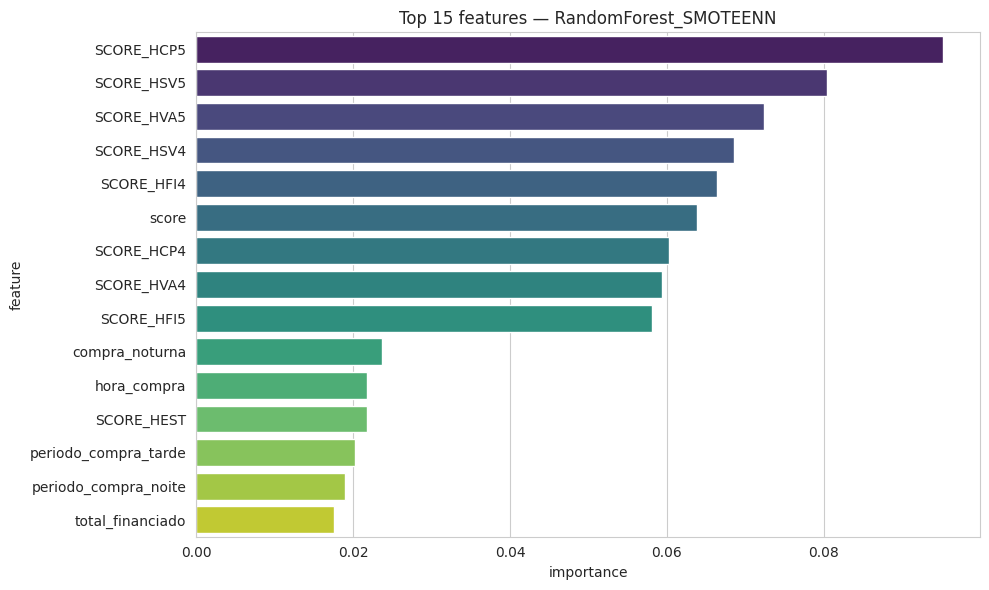

             feature  importance
          SCORE_HCP5    0.095130
          SCORE_HSV5    0.080338
          SCORE_HVA5    0.072405
          SCORE_HSV4    0.068575
          SCORE_HFI4    0.066371
               score    0.063814
          SCORE_HCP4    0.060213
          SCORE_HVA4    0.059393
          SCORE_HFI5    0.058108
      compra_noturna    0.023747
         hora_compra    0.021846
          SCORE_HEST    0.021799
periodo_compra_tarde    0.020206
periodo_compra_noite    0.018956
    total_financiado    0.017602


In [19]:
if hasattr(champion, 'feature_importances_'):
    feat_imp = pd.DataFrame({
        'feature': X_train.columns,
        'importance': champion.feature_importances_
    }).sort_values('importance', ascending=False).head(15)
    
    plt.figure(figsize=(10,6))
    sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis')
    plt.title(f'Top 15 features — {champ_name}')
    plt.tight_layout()
    plt.show()
    print(feat_imp.to_string(index=False))
elif hasattr(champion, 'coef_'):
    feat_imp = pd.DataFrame({
        'feature': X_train.columns,
        'coef': champion.coef_[0]
    })
    feat_imp['abs'] = feat_imp['coef'].abs()
    feat_imp = feat_imp.sort_values('abs', ascending=False).head(15)
    print(feat_imp[['feature','coef']].to_string(index=False))